**1. 依序生成各個系統的運算結果**

In [1]:
import os
import json
import requests
from dotenv import load_dotenv
from smart_book_seeker import ConversationManager
load_dotenv()

ES_API_URL = os.getenv("ES_API_URL")
ES_API_KEY = os.getenv("ES_API_KEY")
header = {
    "Authorization": f"Apikey {ES_API_KEY}",
    "Content-Type": "application/json"
}
for i in range(1, 101):
    # Ground Truth
    filename = f"../results/ground_truth/{i:03}.json"
    with open(filename, "r", encoding="utf-8") as f:
        ground_truth = json.load(f)
    print(f"[{i:03}/100] Ground Truth ✓")

    # Baseline (BM25)
    baseline_bm25 = {"user_book_needs": ground_truth["user_book_needs"], "books": []}
    post_data = {
        "query": {
            "simple_query_string": {
                "query": ground_truth["user_book_needs"]
            }
        }
    }
    response = requests.get(f"{ES_API_URL}/books/_search?size=10", headers=header, json=post_data)
    for book in response.json()["hits"]["hits"]:
        baseline_bm25["books"].append({
            "id": book["_source"]["id"],
            "title": book["_source"]["title"]
        })
    filename = f"../results/baseline_bm25/{i:03}.json"
    with open(filename, "w", encoding="utf-8") as f:
        json.dump(baseline_bm25, f, indent=2, ensure_ascii=False)
    print(f"[{i:03}/100] Baseline (BM25) ✓")

    # Baseline [Librarian]
    baseline_librarian = {"user_book_needs": ground_truth["user_book_needs"], "books": []}
    cm = ConversationManager(strategy="iterative_top_k")
    for response in cm.search_only(ground_truth["user_book_needs"]):
        pass
    for book in cm.user_agent.environment.current_books:
        baseline_librarian["books"].append({
            "id": book.id,
            "title": book.title
        })
    filename = f"../results/baseline_librarian/{i:03}.json"
    with open(filename, "w", encoding="utf-8") as f:
        json.dump(baseline_librarian, f, indent=2, ensure_ascii=False)
    print(f"[{i:03}/100] Baseline (Librarian) ✓")

    # Smart Book Seeker
    sbs = {"user_book_needs": ground_truth["user_book_needs"], "books": []}
    cm = ConversationManager(strategy="iterative_top_k")
    max_retries = 10
    retry_count = 0
    while retry_count < max_retries:
        try:
            for response in cm.discuss(book_search_needs=sbs["user_book_needs"]):
                pass
            break
        except ValueError as e:
            retry_count += 1
            print(f"[{i:03}/100] SBS ✗ ({e}, {retry_count}/{max_retries})")
            if retry_count == max_retries:
                print(f"[{i:03}/100] SBS ✗ (Max retries reached)")
                break
    if retry_count >= max_retries:
        print("Exit due to max retries")
        break
    for book in cm.user_agent.environment.current_books:
        sbs["books"].append({
            "id": book.id,
            "title": book.title
        })
    filename = f"../results/smart_book_seeker/{i:03}.json"
    with open(filename, "w", encoding="utf-8") as f:
        json.dump(sbs, f, indent=2, ensure_ascii=False)
    print(f"[{i:03}/100] Smart Book Seeker ✓")

[001/100] Ground Truth ✓
[001/100] Baseline (BM25) ✓
[001/100] Baseline (Librarian) ✓
[001/100] Smart Book Seeker ✓
[002/100] Ground Truth ✓
[002/100] Baseline (BM25) ✓
[002/100] Baseline (Librarian) ✓
[002/100] Smart Book Seeker ✓
[003/100] Ground Truth ✓
[003/100] Baseline (BM25) ✓
[003/100] Baseline (Librarian) ✓
[003/100] Smart Book Seeker ✓
[004/100] Ground Truth ✓
[004/100] Baseline (BM25) ✓
[004/100] Baseline (Librarian) ✓
[004/100] Smart Book Seeker ✓
[005/100] Ground Truth ✓
[005/100] Baseline (BM25) ✓
[005/100] Baseline (Librarian) ✓
[005/100] Smart Book Seeker ✓
[006/100] Ground Truth ✓
[006/100] Baseline (BM25) ✓
[006/100] Baseline (Librarian) ✓
[006/100] Smart Book Seeker ✓
[007/100] Ground Truth ✓
[007/100] Baseline (BM25) ✓
[007/100] Baseline (Librarian) ✓
[007/100] Smart Book Seeker ✓
[008/100] Ground Truth ✓
[008/100] Baseline (BM25) ✓
[008/100] Baseline (Librarian) ✓
[008/100] Smart Book Seeker ✓
[009/100] Ground Truth ✓
[009/100] Baseline (BM25) ✓
[009/100] Baseline 

**2. 計算成績**

In [2]:
import json
import numpy as np

# load results
result_ground_truth = []
result_baseline_bm25 = []
result_baseline_librarian = []
result_sbs = []
for i in range(1, 101):
    filename = f"../results/ground_truth/{i:03}.json"
    with open(filename, "r", encoding="utf-8") as f:
        result_ground_truth.append(json.load(f))
    filename = f"../results/baseline_bm25/{i:03}.json"
    with open(filename, "r", encoding="utf-8") as f:
        result_baseline_bm25.append(json.load(f))
    filename = f"../results/baseline_librarian/{i:03}.json"
    with open(filename, "r", encoding="utf-8") as f:
        result_baseline_librarian.append(json.load(f))
    filename = f"../results/smart_book_seeker/{i:03}.json"
    with open(filename, "r", encoding="utf-8") as f:
        result_sbs.append(json.load(f))

# calculate scores
score_baseline_bm25 = []
score_baseline_librarian = []
score_sbs = []
for i, result in enumerate(result_ground_truth):
    score_baseline_bm25.append(0)
    score_baseline_librarian.append(0)
    score_sbs.append(0)
    for book in result_baseline_bm25[i]["books"]:
        for ans_book in result["books"]:
            if book["id"] == ans_book["id"]:
                score_baseline_bm25[i] += 10
    for book in result_baseline_librarian[i]["books"]:
        for ans_book in result["books"]:
            if book["id"] == ans_book["id"]:
                score_baseline_librarian[i] += 10
    for book in result_sbs[i]["books"]:
        for ans_book in result["books"]:
            if book["id"] == ans_book["id"]:
                score_sbs[i] += 10

# calculate average, variance, median, std
avg_baseline_bm25 = sum(score_baseline_bm25) / len(score_baseline_bm25)
var_baseline_bm25 = np.var(score_baseline_bm25)
median_baseline_bm25 = np.median(score_baseline_bm25)
std_baseline_bm25 = np.std(score_baseline_bm25)
avg_baseline_librarian = sum(score_baseline_librarian) / len(score_baseline_librarian)
var_baseline_librarian = np.var(score_baseline_librarian)
median_baseline_librarian = np.median(score_baseline_librarian)
std_baseline_librarian = np.std(score_baseline_librarian)
avg_sbs = sum(score_sbs) / len(score_sbs)
var_sbs = np.var(score_sbs)
median_sbs = np.median(score_sbs)
std_sbs = np.std(score_sbs)

print(f"Baseline (BM25):      avg={avg_baseline_bm25:.2f}, var={var_baseline_bm25:.2f}, median={median_baseline_bm25:.2f}, std={std_baseline_bm25:.2f}")
print(f"Baseline (Librarian): avg={avg_baseline_librarian:.2f}, var={var_baseline_librarian:.2f}, median={median_baseline_librarian:.2f}, std={std_baseline_librarian:.2f}")
print(f"Smart Book Seeker:    avg={avg_sbs:.2f}, var={var_sbs:.2f}, median={median_sbs:.2f}, std={std_sbs:.2f}")

Baseline (BM25):      avg=28.00, var=556.00, median=25.00, std=23.58
Baseline (Librarian): avg=22.00, var=796.00, median=10.00, std=28.21
Smart Book Seeker:    avg=37.00, var=1001.00, median=30.00, std=31.64


**3. 畫圖**

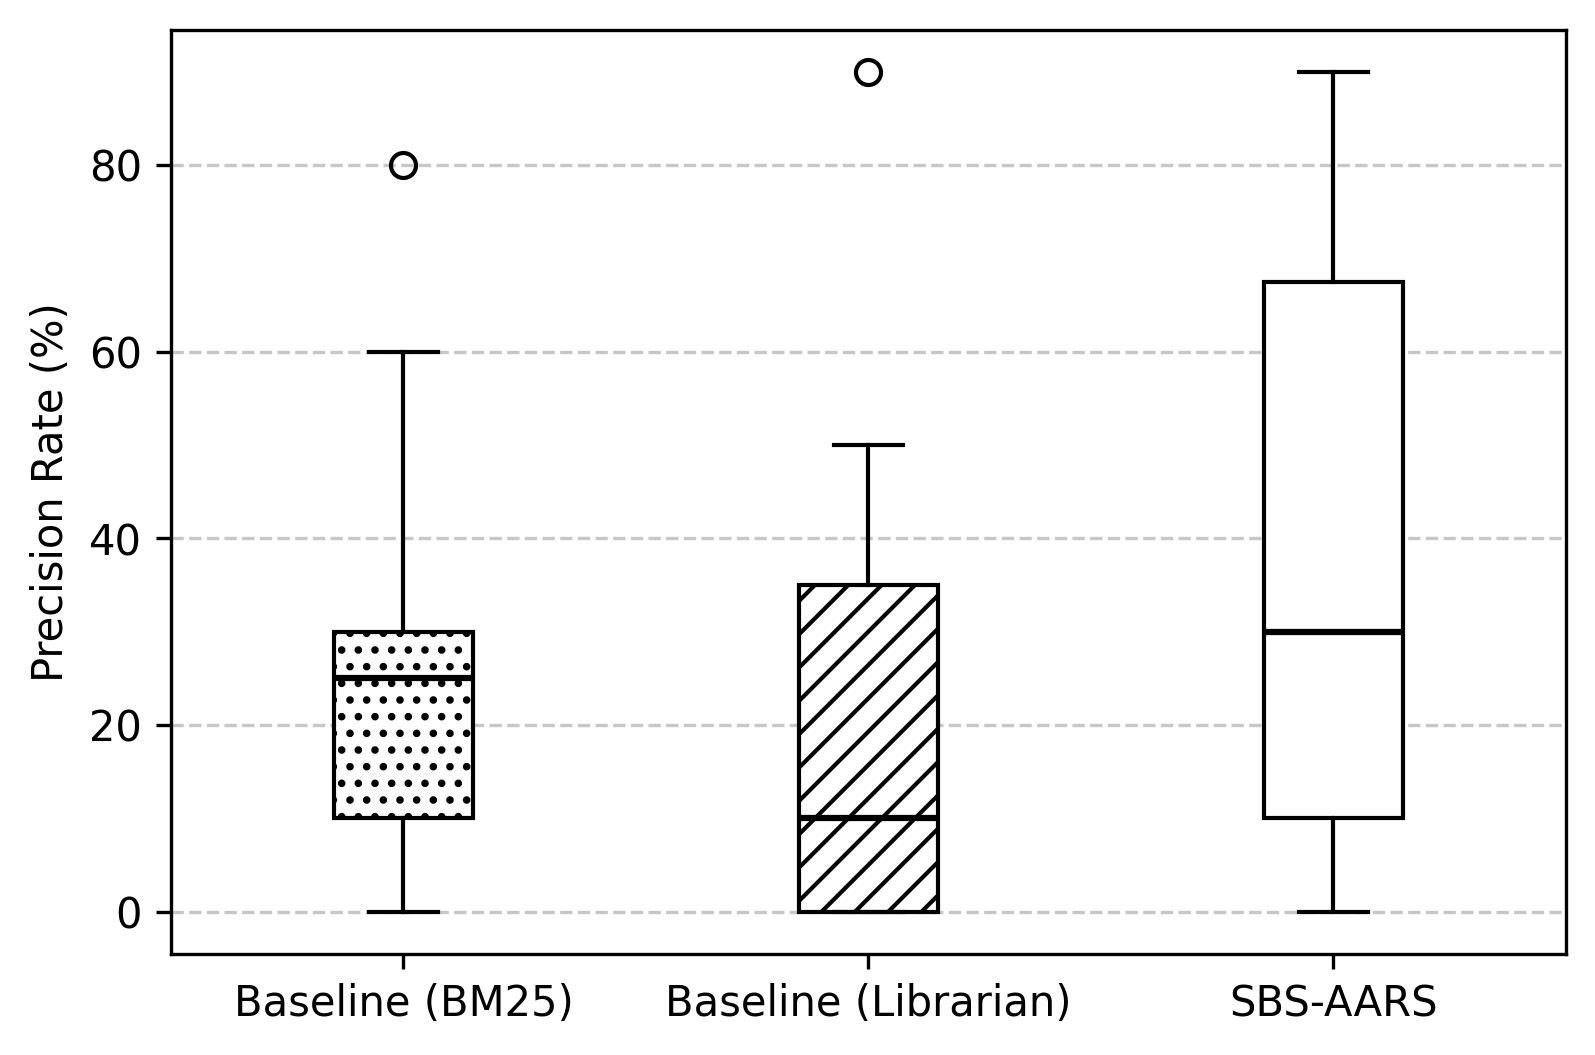

In [4]:
import matplotlib.pyplot as plt

data   = [score_baseline_bm25, score_baseline_librarian, score_sbs]
labels = ['Baseline (BM25)', 'Baseline (Librarian)', 'SBS-AARS']

plt.figure(figsize=(6, 4), dpi=300)
box = plt.boxplot(
    data,
    patch_artist=True,
    boxprops=dict(color='black'),
    medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black')
)
hatches = ['...', '///', '']
for patch, hatch in zip(box['boxes'], hatches):
    patch.set_facecolor('white')
    patch.set_hatch(hatch)
    patch.set_edgecolor('black')
plt.xticks([1, 2, 3], labels)
plt.ylabel('Precision Rate (%)')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
# plt.title('Baseline v.s. SBS-AARS')
# legend_elements = [
#     Patch(facecolor='white', edgecolor='black', hatch=hatches[0],
#           label=f'Baseline (Average = {avg1:.2f}%)'),
#     Patch(facecolor='white', edgecolor='black', hatch=hatches[1],
#           label=f'Smart Book Seeker (Average = {avg2:.2f}%)')
# ]
# plt.legend(handles=legend_elements, loc='upper left')

plt.savefig('../logs/boxplot.pdf')
plt.show()
plt.close()